In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/fraud_data_cleaned.csv')
print("Shape:", df.shape)
df.head()

Shape: (151112, 11)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [7]:
print("Class distribution:\n", df['class'].value_counts())
print("Fraud percentage:", df['class'].mean() * 100)

Class distribution:
 class
0    136961
1     14151
Name: count, dtype: int64
Fraud percentage: 9.364577267192546


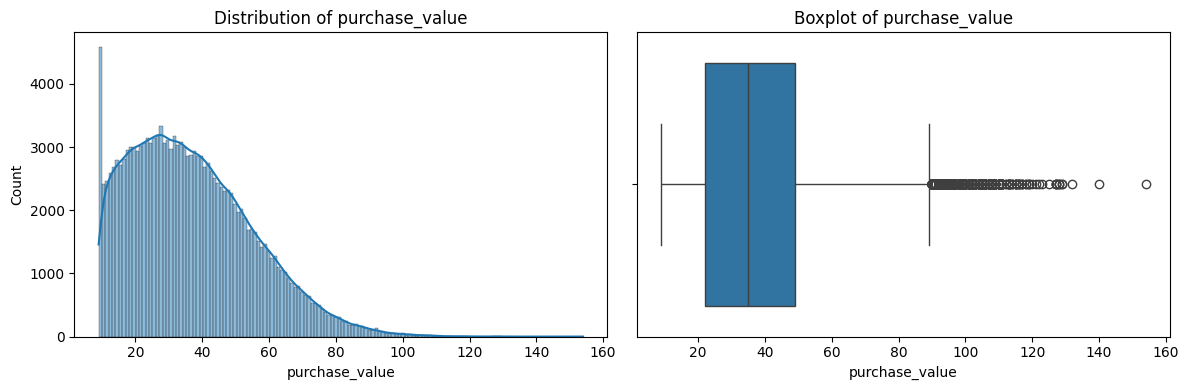

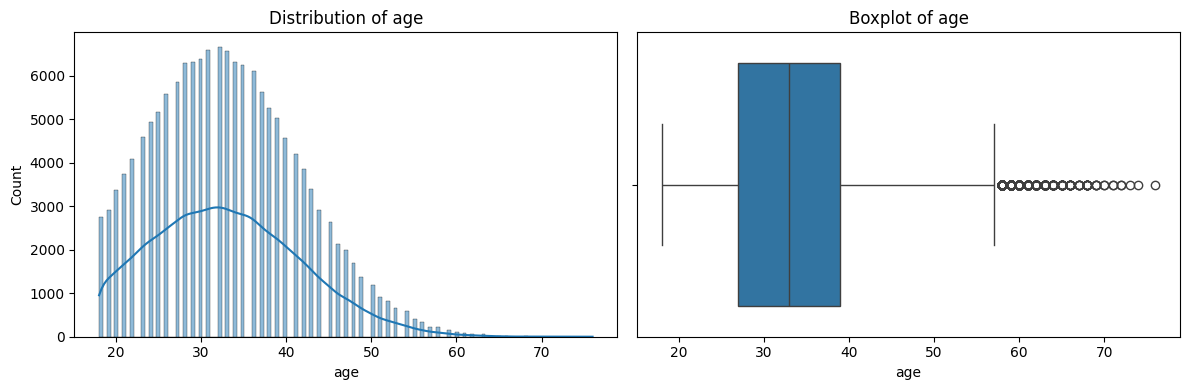

In [8]:
num_cols = ['purchase_value', 'age']
for col in num_cols:
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

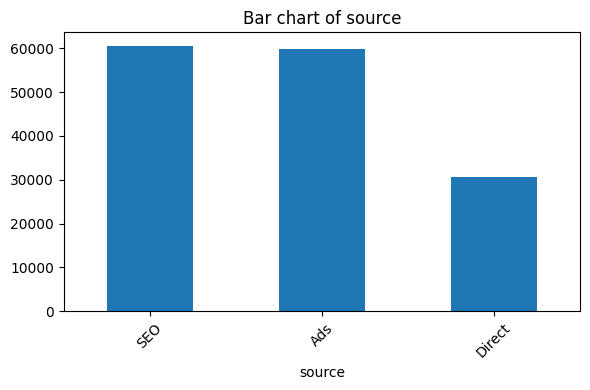

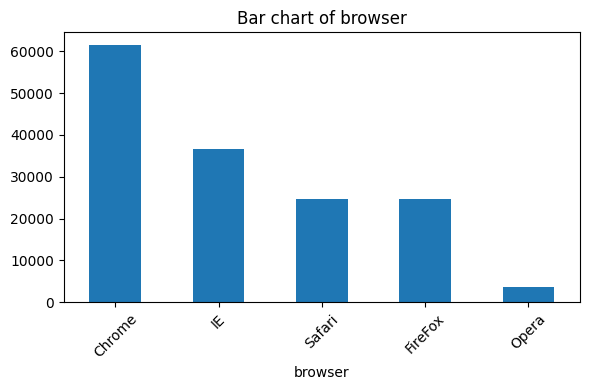

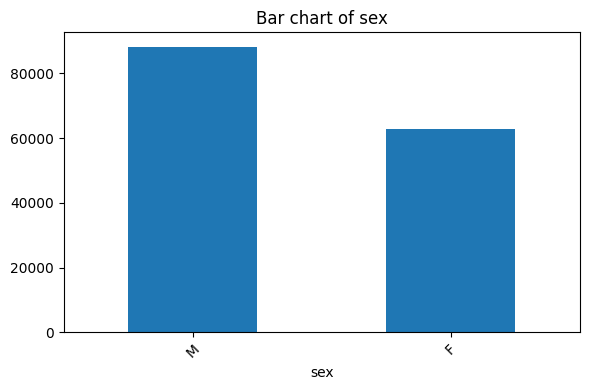

In [9]:
cat_cols = ['source', 'browser', 'sex']
for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Bar chart of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

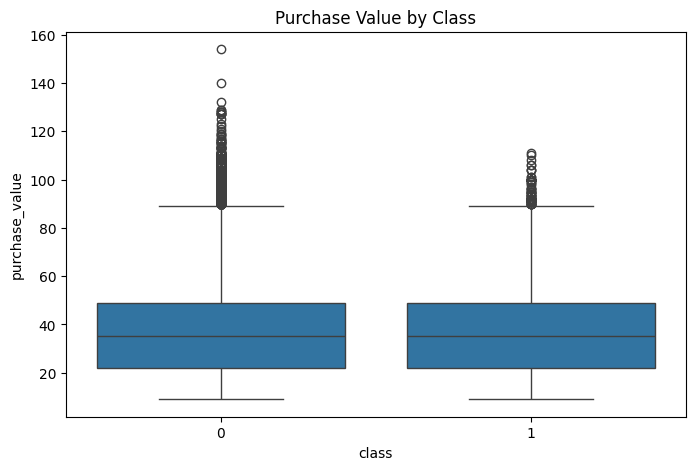

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='class', y='purchase_value')
plt.title('Purchase Value by Class')
plt.show()

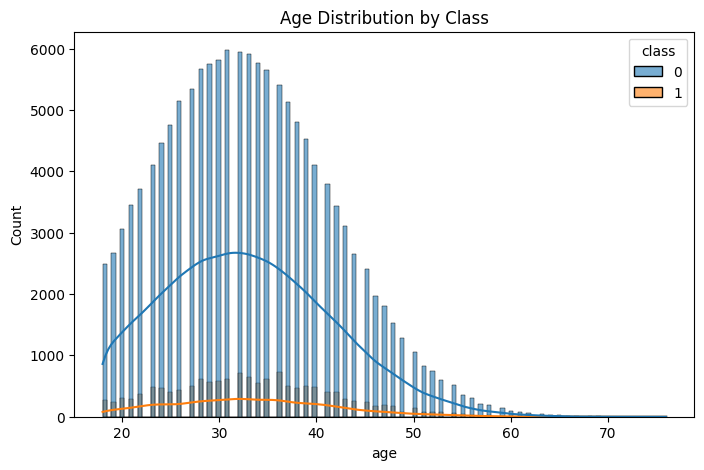

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue='class', kde=True, alpha=0.6)
plt.title('Age Distribution by Class')
plt.show()

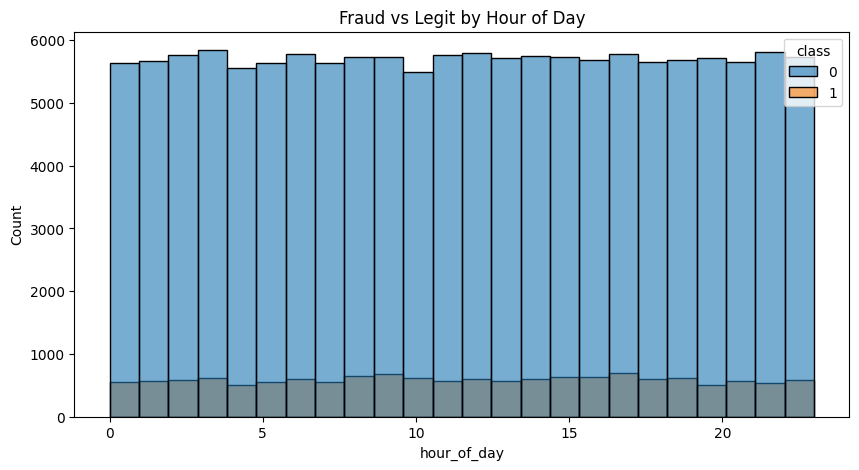

In [12]:
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])
df['hour_of_day'] = df['purchase_time'].dt.hour
df['day_of_week'] = df['purchase_time'].dt.dayofweek
df['time_since_signup'] = (df['purchase_time'] - df['signup_time']).dt.total_seconds() / 3600

plt.figure(figsize=(10,5))
sns.histplot(data=df, x='hour_of_day', hue='class', bins=24, alpha=0.6)
plt.title('Fraud vs Legit by Hour of Day')
plt.show()

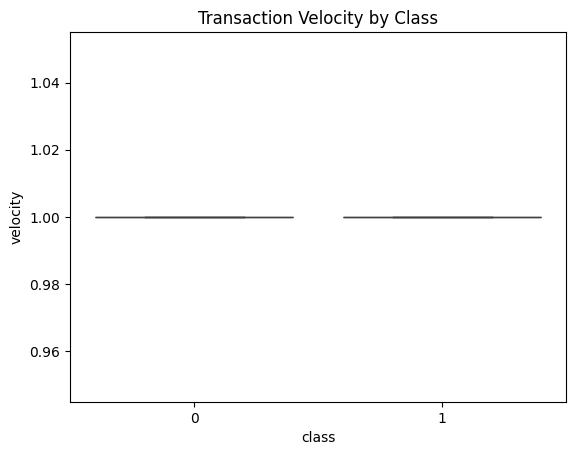

In [13]:
velocity = df.groupby('user_id')['purchase_time'].count().rename('velocity')
df = df.merge(velocity, left_on='user_id', right_index=True)
sns.boxplot(data=df, x='class', y='velocity')
plt.title('Transaction Velocity by Class')
plt.show()

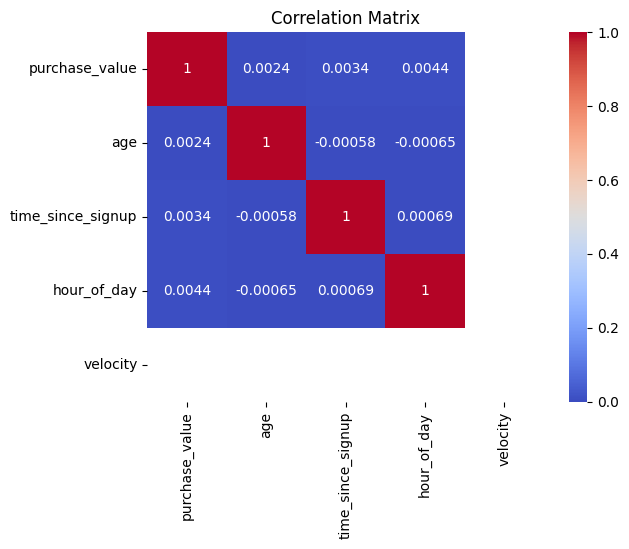

In [14]:
corr_cols = ['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 'velocity']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()